In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns
import math
from datetime import datetime, timedelta, timezone
# import  chi2_contingency
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


In [24]:
data = pd.read_csv('advertisement.csv', dtype=str)

In [25]:
DROP_CLUMNS = ['Mã người đăng', 'Mã bài đăng', 'Mã dự án', 'Cập nhât lần cuối', 'Tọa độ', 'Tọa độ ID', 'Giá (chữ)', 'Hình thức', 'Tỉnh/Thành phố mới', 'Mức độ quảng cáo']
data = data.drop(columns=DROP_CLUMNS)

In [26]:

if data['Số tầng'].dtype == 'object':
    data['Số tầng'] = pd.to_numeric(data['Số tầng'], errors='coerce')
    
if data['Kinh độ'].dtype == 'object':
    data['Kinh độ'] = pd.to_numeric(data['Kinh độ'], errors='coerce')
if data['Vĩ độ'].dtype == 'object':
    data['Vĩ độ'] = pd.to_numeric(data['Vĩ độ'], errors='coerce')

if data['Ngày đăng'].dtype == 'object':
    data['Ngày đăng'] = pd.to_datetime(data['Ngày đăng'], errors='coerce')

if data['Đăng bởi Đối tác'].dtype == 'object':
    data['Đăng bởi Đối tác'] = data['Đăng bởi Đối tác'].map({'True': True, 'False': False, '1': True, '0': False})

if data['Có hướng ra đường'].dtype == 'object':
    data['Có hướng ra đường'] = data['Có hướng ra đường'].map({'True': True, 'False': False, '1': True, '0': False})
    
if data['Đơn giá (tr/m2)'].dtype == 'object':
    data['Đơn giá (tr/m2)'] = pd.to_numeric(
    data['Đơn giá (tr/m2)'].str.replace(r'[^0-9.]', '', regex=True),
    errors='coerce'
).astype('float')

data['Số phòng ngủ'] = (data['Số phòng ngủ']
        .str.replace(r'(?i)\s*pn$', '', regex=True)
        .replace(r'(?i)^none$', np.nan, regex=True))

data['Giá bán'] = (
    data['Giá bán'].astype(str)
    .str.replace("tr/m²", "", regex=False)
    .str.replace("tr/m2", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.extract(r"([0-9]+(?:\.[0-9]+)?)")[0]
    .astype(float)
)


if data['Chiều dài'].dtype == 'object':
    data['Chiều dài'] = pd.to_numeric(
    data['Chiều dài']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)

if data['Chiều rộng'].dtype == 'object':
    data['Chiều rộng'] = pd.to_numeric(
    data['Chiều rộng']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)
   
if data['Diện tích'].dtype == 'object':
    data['Diện tích'] = pd.to_numeric(
    data['Diện tích']
        .astype('string')
        .fillna('')
        .str.strip()
        .str.replace(r'(?i)^none\s*m2?$', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
    errors='coerce'
)


In [27]:
for column in data.columns:
    print(f"Column: {column}, dtype: {data[column].dtype}")
    print(f"Unique values: {data[column].unique()}")
    print(f"Number of unique values: {data[column].nunique()}")
    

Column: Tỉnh/Thành phố cũ, dtype: object
Unique values: ['Tp Hồ Chí Minh' 'Bình Dương' 'Bà Rịa - Vũng Tàu']
Number of unique values: 3
Column: Huyện/Quận cũ, dtype: object
Unique values: ['Quận 7' 'Thành phố Thủ Đức' 'Quận 8' 'Huyện Nhà Bè' 'Thành phố Dĩ An'
 'Quận 4' 'Quận 12' 'Huyện Bình Chánh' 'Quận 1' 'Thành phố Thuận An'
 'Quận 10' 'Quận Bình Thạnh' 'Quận Phú Nhuận' 'Quận Bình Tân'
 'Quận Tân Phú' 'Thành phố Thủ Dầu Một' 'Quận Gò Vấp' 'Quận Tân Bình'
 'Quận 3' 'Thành phố Vũng Tàu' 'Thị xã Bến Cát' 'Huyện Hóc Môn' 'Quận 6'
 'Thị xã Phú Mỹ' 'Quận 5' 'Quận 11' 'Thị xã Tân Uyên' 'Huyện Xuyên Mộc'
 'Thành phố Bà Rịa' 'Huyện Long Điền' 'Huyện Cần Giờ' 'Huyện Dầu Tiếng'
 'Huyện Củ Chi' 'Huyện Bàu Bàng' 'Huyện Châu Đức' 'Huyện Phú Giáo'
 'Huyện Đất Đỏ' 'Huyện Bắc Tân Uyên' 'Huyện Côn Đảo']
Number of unique values: 39
Column: Phường/Xã cũ, dtype: object
Unique values: ['Phường Tân Hưng' 'Phường Trường Thọ (Quận Thủ Đức cũ)' 'Phường 16'
 'Xã Phú Xuân' 'Phường Bình Thắng' 'Phường 18' 'Phường

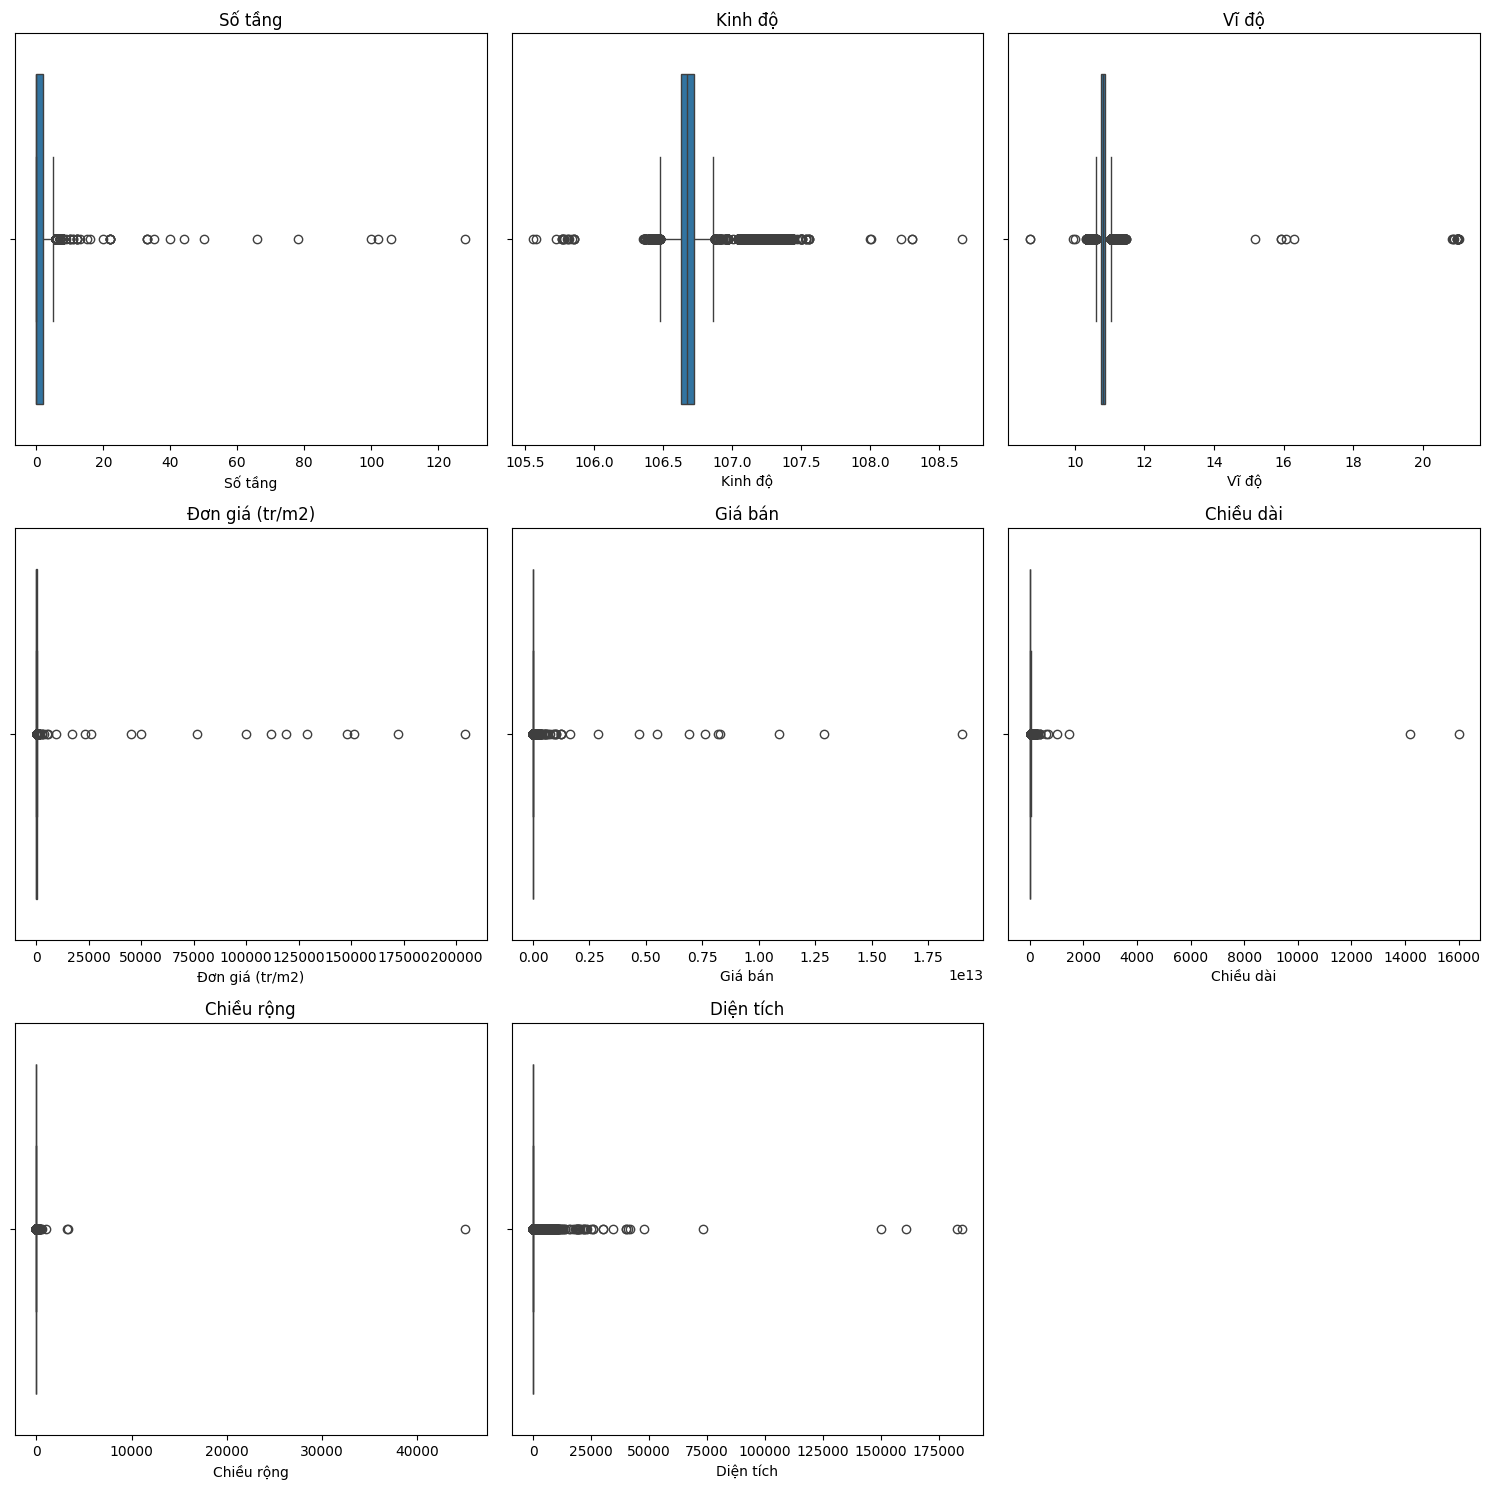

In [28]:
numeric_columns = [
    'Số tầng', 'Kinh độ', 'Vĩ độ', 
    'Đơn giá (tr/m2)', 'Giá bán', 
    'Chiều dài', 'Chiều rộng', 'Diện tích'
]

n_cols = 3  # số cột hiển thị
n_rows = math.ceil(len(numeric_columns) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=data[column])
    plt.title(column)

plt.tight_layout()
plt.show()


,count,median,mean,std
Loại hình,,,,
Nhà ở,23745,105.833336,174.760192,2763.247308
"Văn phòng, Mặt bằng kinh doanh",526,64.500000,106.562104,133.879991
Căn hộ/Chung cư,5819,50.000000,57.049550,35.993609
Đất,8441,36.666668,46.195901,83.460318


Kruskal-Wallis: H = 11867.5504, p = 0


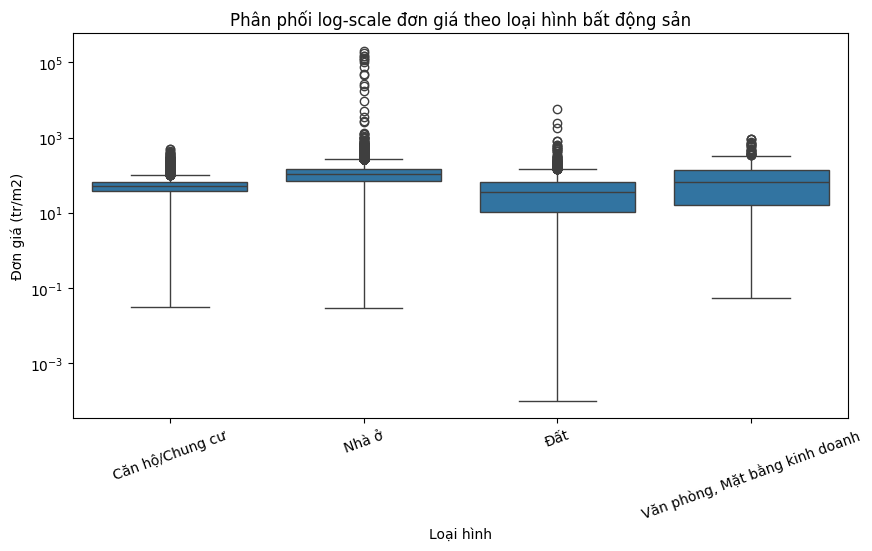

,pair,p_value,p_adjusted
0,"(Căn hộ/Chung cư, Nhà ở)",0.000000e+00,0.000000e+00
3,"(Nhà ở, Đất)",0.000000e+00,0.000000e+00
1,"(Căn hộ/Chung cư, Đất)",1.508159e-153,9.048952e-153
5,"(Đất, Văn phòng, Mặt bằng kinh doanh)",5.316921e-28,3.190153e-27
4,"(Nhà ở, Văn phòng, Mặt bằng kinh doanh)",9.478315e-25,5.686989e-24
2,"(Căn hộ/Chung cư, Văn phòng, Mặt bằng kinh doanh)",2.249808e-07,1.349885e-06


In [30]:

price_col = "Đơn giá (tr/m2)"
type_col = "Loại hình"


work = data[[type_col, price_col]].dropna().copy()
work[type_col] = work[type_col].astype(str).str.strip()

counts = work[type_col].value_counts()
valid_types = counts[counts >= 30].index
work = work[work[type_col].isin(valid_types)]

summary = (
    work.groupby(type_col)[price_col]
    .agg(["count", "median", "mean", "std"])
    .sort_values("median", ascending=False)
)
display(summary)

samples = [g[price_col].values for _, g in work.groupby(type_col)]
H, p = kruskal(*samples)
print(f"Kruskal-Wallis: H = {H:.4f}, p = {p:.6g}")

plt.figure(figsize=(10, 5))
sns.boxplot(data=work, x=type_col, y=price_col)
plt.yscale("log")
plt.xticks(rotation=20)
plt.title("Phân phối log-scale đơn giá theo loại hình bất động sản")
plt.show()

pairs = []
pvals = []
for a, b in combinations(work[type_col].unique(), 2):
    x = work.loc[work[type_col] == a, price_col]
    y = work.loc[work[type_col] == b, price_col]
    _, p_pair = mannwhitneyu(x, y, alternative="two-sided")
    pairs.append((a, b))
    pvals.append(p_pair)

adj = multipletests(pvals, method="bonferroni")[1]
pairwise_df = pd.DataFrame({
    "pair": pairs,
    "p_value": pvals,
    "p_adjusted": adj
}).sort_values("p_adjusted")

display(pairwise_df)


In [31]:
# Count outliers
for column in numeric_columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"Number of outliers in {column}: {len(outliers)}")

Number of outliers in Số tầng: 267
Number of outliers in Kinh độ: 1485
Number of outliers in Vĩ độ: 2613
Number of outliers in Đơn giá (tr/m2): 1173
Number of outliers in Giá bán: 3149
Number of outliers in Chiều dài: 2090
Number of outliers in Chiều rộng: 3806
Number of outliers in Diện tích: 4454


Text(0.5, 1.0, 'Correlation Heatmap')

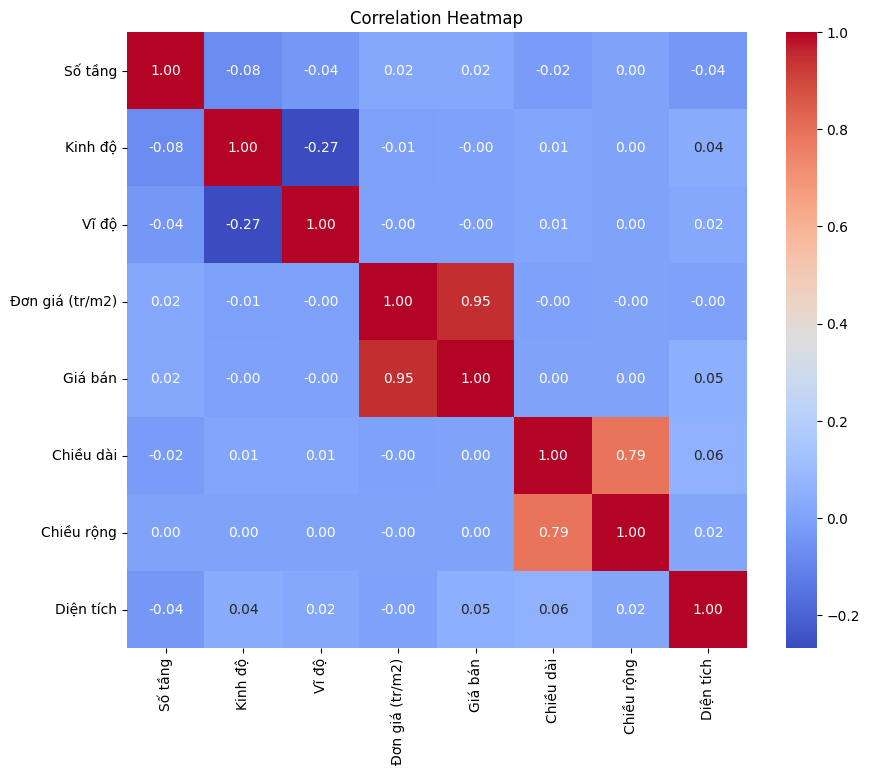

In [32]:
# Vẽ heatmap để kiểm tra tương quan giữa các biến số so với biến mục tiêu 'Giá bán'
plt.figure(figsize=(10, 8))
correlation_matrix = data[numeric_columns].corr()  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

,Giá bán nhóm,Đường,Số phòng vệ sinh,Số phòng ngủ,Số nhà,Phường/Xã cũ,Phường mới,Huyện/Quận cũ,Loại hình nhà ở,Giấy tờ pháp lý,...,Loại hình văn phòng,Đặc điểm nhà/đất,Loại hình căn hộ,Tình trạng nội thất,Loại hình đất,Đăng bởi Đối tác,Hướng đất,Hướng ban công,Ngày đăng,Hướng cửa chính
Giá bán nhóm,1.000,0.373,0.360,0.348,0.328,0.319,0.309,0.273,0.246,0.237,...,0.200,0.165,0.142,0.137,0.079,0.057,0.044,0.037,0.031,0.012
Đường,0.373,1.000,0.291,0.257,0.388,0.672,0.684,0.763,0.396,0.324,...,0.375,0.309,0.510,0.266,0.391,0.287,0.216,0.282,0.076,0.221
Số phòng vệ sinh,0.360,0.291,1.000,0.571,0.331,0.175,0.165,0.128,0.149,0.201,...,NaN,0.096,0.331,0.174,NaN,0.045,NaN,0.000,0.000,0.018
Số phòng ngủ,0.348,0.257,0.571,1.000,0.255,0.118,0.113,0.083,0.151,0.158,...,NaN,0.078,0.335,0.156,NaN,0.041,NaN,0.000,0.000,0.018
Số nhà,0.328,0.388,0.331,0.255,1.000,0.383,0.392,0.398,0.071,0.158,...,0.000,0.000,0.578,0.305,0.326,0.000,0.098,0.279,0.000,0.151
Phường/Xã cũ,0.319,0.672,0.175,0.118,0.383,1.000,0.871,0.845,0.268,0.217,...,0.305,0.132,0.254,0.163,0.358,0.340,0.205,0.212,0.000,0.166
Phường mới,0.309,0.684,0.165,0.113,0.392,0.871,1.000,0.986,0.255,0.198,...,0.315,0.116,0.219,0.176,0.310,0.327,0.182,0.180,0.035,0.159
Huyện/Quận cũ,0.273,0.763,0.128,0.083,0.398,0.845,0.986,1.000,0.195,0.137,...,0.211,0.154,0.151,0.126,0.222,0.280,0.140,0.133,0.000,0.137
Loại hình nhà ở,0.246,0.396,0.149,0.151,0.071,0.268,0.255,0.195,1.000,0.064,...,NaN,0.061,NaN,0.073,NaN,0.050,NaN,NaN,0.071,0.008
Giấy tờ pháp lý,0.237,0.324,0.201,0.158,0.158,0.217,0.198,0.137,0.064,1.000,...,0.357,0.161,0.056,0.102,0.153,0.057,0.045,0.055,0.094,0.047


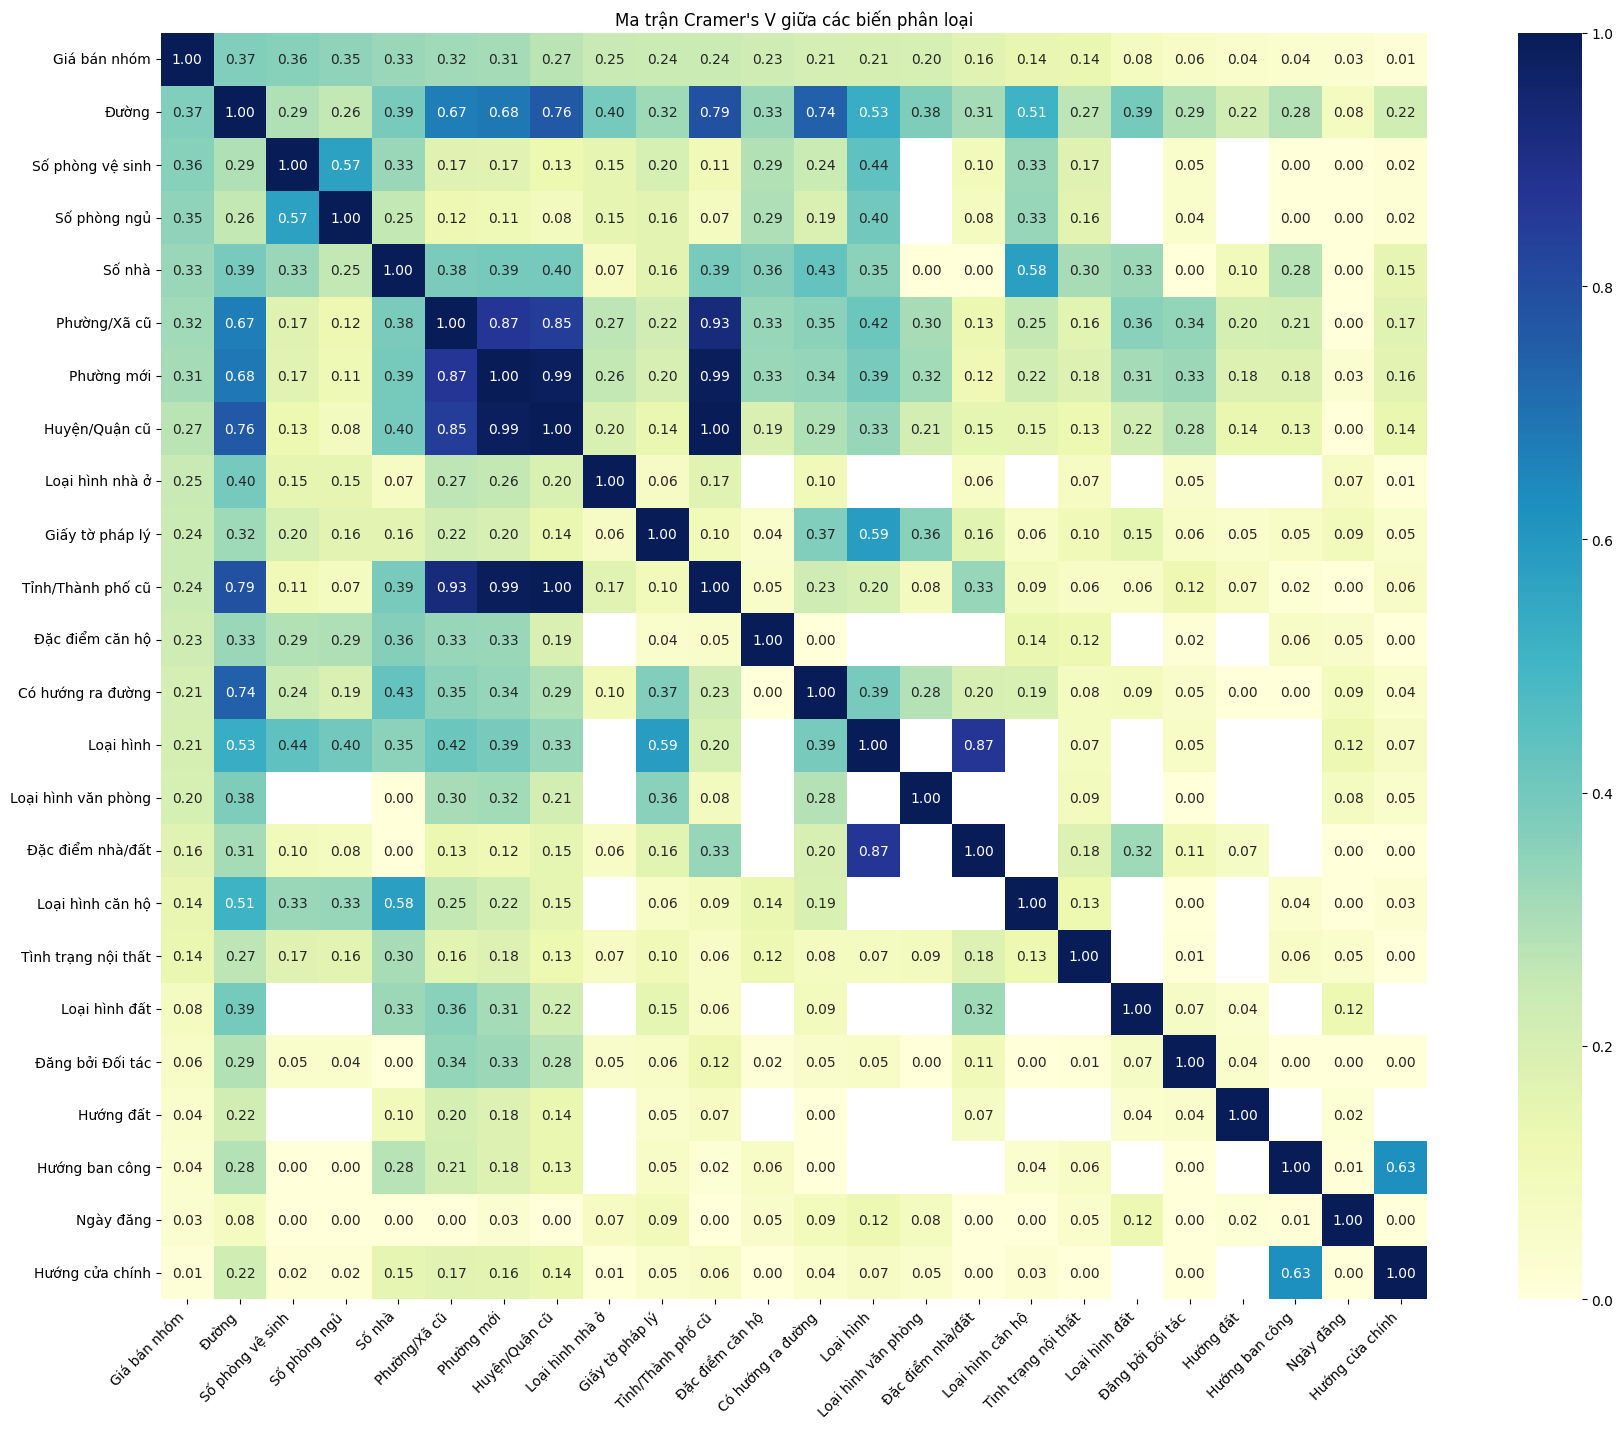

In [ ]:
# Vẽ ma trận tương quan Cramer's V giữa các biến phân loại
target_col = 'Giá bán'
columns_lists = data.select_dtypes(include=['object', 'bool']).columns.tolist()
for extra_col in ['Ngày đăng', 'Ngay đăng']:
    if extra_col in data.columns and extra_col not in columns_lists:
        columns_lists.append(extra_col)

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        return np.nan

    n = contingency_table.to_numpy().sum()
    if n <= 1:
        return np.nan

    chi2 = chi2_contingency(contingency_table)[0]
    r, k = contingency_table.shape
    phi2 = chi2 / n

    # Bias-corrected Cramer's V để kết quả ổn định hơn.
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denominator = min(kcorr - 1, rcorr - 1)

    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2corr / denominator)

analysis_df = data[columns_lists + [target_col]].copy()
analysis_df['Giá bán nhóm'] = pd.qcut(analysis_df[target_col], q=5, duplicates='drop')

categorical_cols = columns_lists + ['Giá bán nhóm']
cramers_v_matrix = pd.DataFrame(
    np.eye(len(categorical_cols)),
    index=categorical_cols,
    columns=categorical_cols
)

for i, col_1 in enumerate(categorical_cols):
    for j in range(i + 1, len(categorical_cols)):
        col_2 = categorical_cols[j]
        temp = analysis_df[[col_1, col_2]].dropna()
        if temp.empty:
            score = np.nan
        else:
            score = cramers_v(temp[col_1].astype(str), temp[col_2].astype(str))

        cramers_v_matrix.loc[col_1, col_2] = score
        cramers_v_matrix.loc[col_2, col_1] = score

sort_order = cramers_v_matrix['Giá bán nhóm'].sort_values(
    ascending=False,
    na_position='last'
).index
cramers_v_matrix = cramers_v_matrix.loc[sort_order, sort_order]

display(cramers_v_matrix.round(3))

plt.figure(figsize=(max(10, len(categorical_cols) * 0.8), max(8, len(categorical_cols) * 0.6)))
sns.heatmap(
    cramers_v_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    square=True
)
plt.title("Ma trận Cramer's V giữa các biến phân loại")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

,Tổ hợp,Các biến,Số biến,Số trạng thái sau gom,Cramer's V với Giá bán,Biến đơn tốt nhất trong tổ hợp,Mức tăng so với biến đơn tốt nhất,Cột thiếu
0,to_hop_4,"Huyện/Quận cũ, Loại hình, Diện tích, Số phòng ...",9,4631,0.574,0.281,0.293,
1,to_hop_5,"Kinh độ, Vĩ độ, Huyện/Quận cũ, Loại hình, Diện...",11,8286,0.568,0.281,0.287,
2,to_hop_10,"Huyện/Quận cũ, Loại hình, Diện tích, Số phòng ...",10,7125,0.564,0.281,0.284,
3,to_hop_7,"Kinh độ, Vĩ độ, Huyện/Quận cũ, Tỉnh/Thành phố ...",13,10149,0.557,0.281,0.276,
4,to_hop_11,"Huyện/Quận cũ, Loại hình, Diện tích, Số phòng ...",10,10202,0.538,0.281,0.258,
5,to_hop_3,"Kinh độ, Vĩ độ, Loại hình, Diện tích, Số phòng...",11,6984,0.536,0.281,0.255,
6,to_hop_1,"Kinh độ, Vĩ độ, Loại hình, Diện tích, Số phòng...",6,2569,0.534,0.281,0.254,
7,to_hop_9,"Kinh độ, Vĩ độ, Loại hình, Diện tích, Số phòng...",12,6374,0.533,0.281,0.252,
8,to_hop_2,"Kinh độ, Vĩ độ, Loại hình, Diện tích, Số phòng...",8,7287,0.523,0.281,0.243,
9,to_hop_13,"Huyện/Quận cũ, Loại hình, Diện tích, Số phòng ...",11,13297,0.521,0.281,0.240,


,Biến 1,Biến 2,Cramer's V giữa 2 biến
0,Huyện/Quận cũ,Tỉnh/Thành phố cũ,1.000
1,Phường mới,Tỉnh/Thành phố cũ,0.994
2,Phường mới,Huyện/Quận cũ,0.986
3,Phường/Xã cũ,Tỉnh/Thành phố cũ,0.928
4,Phường/Xã cũ,Phường mới,0.871
5,Loại hình,Đặc điểm nhà/đất,0.868
6,Phường/Xã cũ,Huyện/Quận cũ,0.845
7,Đường,Tỉnh/Thành phố cũ,0.786
8,Đường,Huyện/Quận cũ,0.763
9,Đường,Có hướng ra đường,0.742


feature_combo_candidates =


{'vi_tri_co_ban': ['Kinh độ', 'Vĩ độ'],
 'vi_tri_va_dien_tich': ['Kinh độ', 'Vĩ độ', 'Diện tích'],
 'vi_tri_va_loai_hinh': ['Kinh độ', 'Vĩ độ', 'Loại hình'],
 'vi_tri_va_loai_hinh_nha_o': ['Kinh độ', 'Vĩ độ', 'Loại hình nhà ở'],
 'vi_tri_va_loai_hinh_can_ho': ['Kinh độ', 'Vĩ độ', 'Loại hình căn hộ'],
 'loai_hinh_chung_va_dien_tich': ['Loại hình', 'Diện tích'],
 'loai_hinh_nha_o_va_dien_tich': ['Loại hình nhà ở', 'Diện tích'],
 'loai_hinh_can_ho_va_dien_tich': ['Loại hình căn hộ', 'Diện tích'],
 'loai_hinh_va_so_phong': ['Loại hình', 'Số phòng ngủ', 'Số phòng vệ sinh'],
 'loai_hinh_nha_o_va_so_phong': ['Loại hình nhà ở',
  'Số phòng ngủ',
  'Số phòng vệ sinh'],
 'loai_hinh_can_ho_va_so_phong': ['Loại hình căn hộ',
  'Số phòng ngủ',
  'Số phòng vệ sinh'],
 'loai_dat_va_dien_tich': ['Loại đất', 'Diện tích'],
 'dia_chi_cu_day_du': ['Tỉnh/Thành phố cũ', 'Huyện/Quận cũ', 'Phường/Xã cũ'],
 'duong_va_vi_tri': ['Đường', 'Kinh độ', 'Vĩ độ'],
 'to_hop_1': ['Kinh độ',
  'Vĩ độ',
  'Loại hình',
  '

strong_pair_list =


[['Đường', 'Phường/Xã cũ'],
 ['Đường', 'Phường mới'],
 ['Đường', 'Huyện/Quận cũ'],
 ['Đường', 'Tỉnh/Thành phố cũ'],
 ['Đường', 'Có hướng ra đường'],
 ['Phường/Xã cũ', 'Phường mới'],
 ['Phường/Xã cũ', 'Huyện/Quận cũ'],
 ['Phường/Xã cũ', 'Tỉnh/Thành phố cũ'],
 ['Phường mới', 'Huyện/Quận cũ'],
 ['Phường mới', 'Tỉnh/Thành phố cũ'],
 ['Huyện/Quận cũ', 'Tỉnh/Thành phố cũ'],
 ['Loại hình', 'Đặc điểm nhà/đất'],
 ['Hướng ban công', 'Hướng cửa chính']]

strong_pair_combo_candidates =


{'strong_pair_1__Đường__Phường/Xã cũ': ['Đường', 'Phường/Xã cũ'],
 'strong_pair_2__Đường__Phường mới': ['Đường', 'Phường mới'],
 'strong_pair_3__Đường__Huyện/Quận cũ': ['Đường', 'Huyện/Quận cũ'],
 'strong_pair_4__Đường__Tỉnh/Thành phố cũ': ['Đường', 'Tỉnh/Thành phố cũ'],
 'strong_pair_5__Đường__Có hướng ra đường': ['Đường', 'Có hướng ra đường'],
 'strong_pair_6__Phường/Xã cũ__Phường mới': ['Phường/Xã cũ', 'Phường mới'],
 'strong_pair_7__Phường/Xã cũ__Huyện/Quận cũ': ['Phường/Xã cũ',
  'Huyện/Quận cũ'],
 'strong_pair_8__Phường/Xã cũ__Tỉnh/Thành phố cũ': ['Phường/Xã cũ',
  'Tỉnh/Thành phố cũ'],
 'strong_pair_9__Phường mới__Huyện/Quận cũ': ['Phường mới', 'Huyện/Quận cũ'],
 'strong_pair_10__Phường mới__Tỉnh/Thành phố cũ': ['Phường mới',
  'Tỉnh/Thành phố cũ'],
 'strong_pair_11__Huyện/Quận cũ__Tỉnh/Thành phố cũ': ['Huyện/Quận cũ',
  'Tỉnh/Thành phố cũ'],
 'strong_pair_12__Loại hình__Đặc điểm nhà/đất': ['Loại hình',
  'Đặc điểm nhà/đất'],
 'strong_pair_13__Hướng ban công__Hướng cửa chính': [

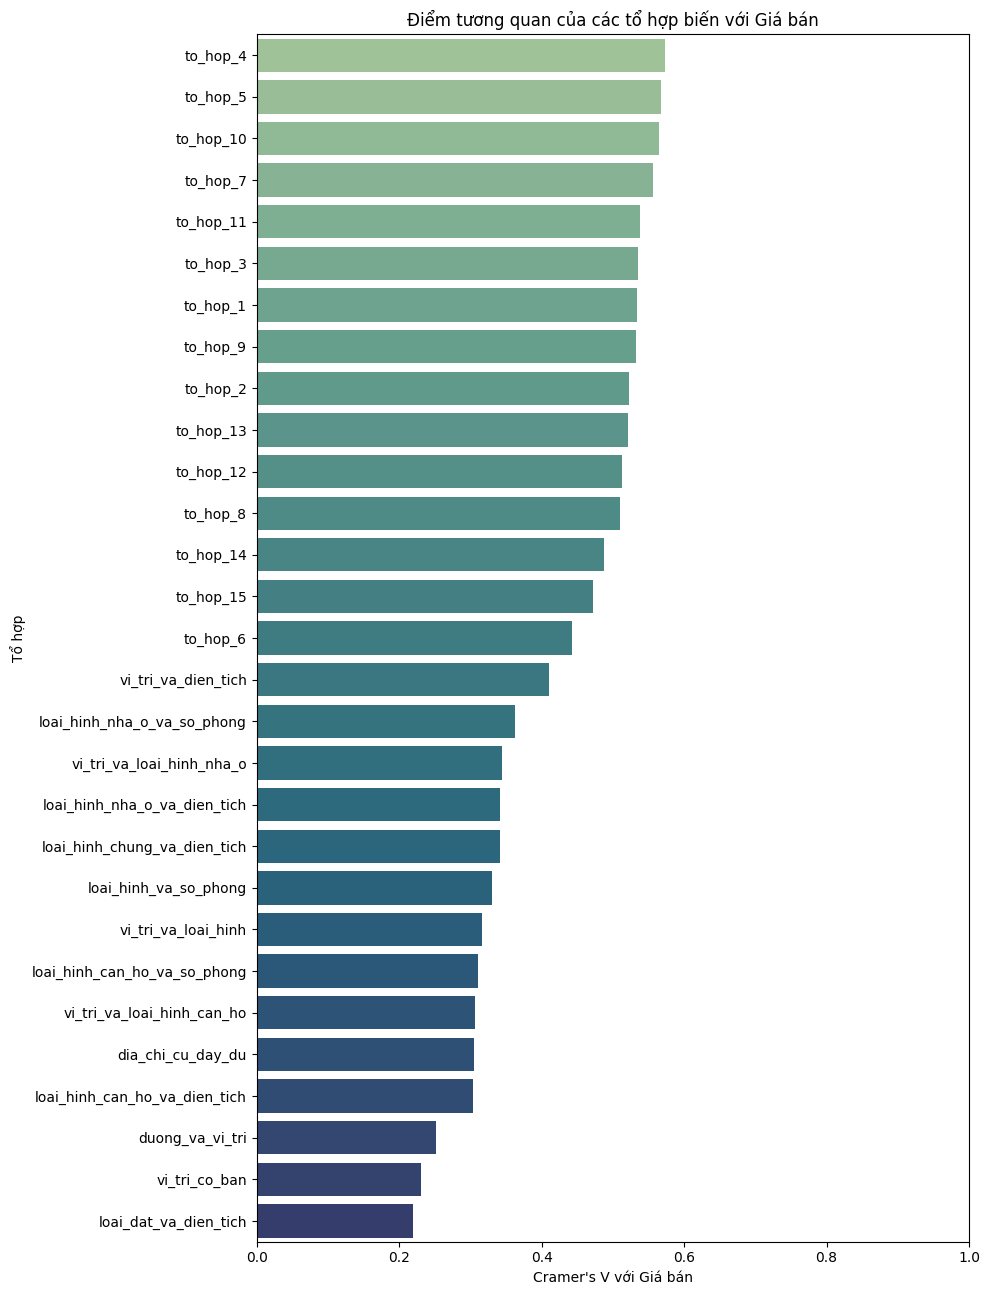

In [34]:
# Đo độ tương quan giữa một số tổ hợp biến và Giá bán
target_col = 'Giá bán'
target_bins = 5
numeric_bins = 5
high_cardinality_top_n = 30
strong_pair_threshold = 0.60

# Bạn có thể thêm tổ hợp mới ở đây nếu muốn.
feature_combo_candidates = {
    'vi_tri_co_ban': ['Kinh độ', 'Vĩ độ'],
    'vi_tri_va_dien_tich': ['Kinh độ', 'Vĩ độ', 'Diện tích'],
    'vi_tri_va_loai_hinh': ['Kinh độ', 'Vĩ độ', 'Loại hình'],
    'vi_tri_va_loai_hinh_nha_o': ['Kinh độ', 'Vĩ độ', 'Loại hình nhà ở'],
    'vi_tri_va_loai_hinh_can_ho': ['Kinh độ', 'Vĩ độ', 'Loại hình căn hộ'],
    'loai_hinh_chung_va_dien_tich': ['Loại hình', 'Diện tích'],
    'loai_hinh_nha_o_va_dien_tich': ['Loại hình nhà ở', 'Diện tích'],
    'loai_hinh_can_ho_va_dien_tich': ['Loại hình căn hộ', 'Diện tích'],
    'loai_hinh_va_so_phong': ['Loại hình', 'Số phòng ngủ', 'Số phòng vệ sinh'],
    'loai_hinh_nha_o_va_so_phong': ['Loại hình nhà ở', 'Số phòng ngủ', 'Số phòng vệ sinh'],
    'loai_hinh_can_ho_va_so_phong': ['Loại hình căn hộ', 'Số phòng ngủ', 'Số phòng vệ sinh'],
    'loai_dat_va_dien_tich': ['Loại đất', 'Diện tích'],
    'dia_chi_cu_day_du': ['Tỉnh/Thành phố cũ', 'Huyện/Quận cũ', 'Phường/Xã cũ'],
    'duong_va_vi_tri': ['Đường', 'Kinh độ', 'Vĩ độ'],
    'to_hop_1': ['Kinh độ', 'Vĩ độ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh'],
    'to_hop_2': ['Kinh độ', 'Vĩ độ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Số tầng', 'Giấy tờ pháp lý'],
    'to_hop_3': ['Kinh độ', 'Vĩ độ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Đường', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
    'to_hop_4': ['Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
    'to_hop_5': ['Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
    'to_hop_6': [ 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Đường', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
    'to_hop_7': [ 'Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Tỉnh/Thành phố cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Đường', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
    'to_hop_8': ['Phường mới', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng'],
    'to_hop_9': ['Kinh độ', 'Vĩ độ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Hướng ban công', 'Hướng đất'],
    'to_hop_10': ['Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Giấy tờ pháp lý'],
    'to_hop_11': ['Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất'],
    'to_hop_12': ['Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất'],
    'to_hop_13': ['Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất', 'Giấy tờ pháp lý'],
    'to_hop_14': ['Kinh độ', 'Vĩ độ', 'Huyện/Quận cũ', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất', 'Giấy tờ pháp lý'],
    'to_hop_15': ['Kinh độ', 'Vĩ độ', 'Đường', 'Loại hình', 'Diện tích', 'Số phòng ngủ', 'Số phòng vệ sinh', 'Loại hình nhà ở', 'Loại hình căn hộ', 'Loại hình đất', 'Loại hình văn phòng', 'Đặc điểm nhà/đất', 'Giấy tờ pháp lý'],
}

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        return np.nan

    n = contingency_table.to_numpy().sum()
    if n <= 1:
        return np.nan

    chi2 = chi2_contingency(contingency_table)[0]
    r, k = contingency_table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denominator = min(kcorr - 1, rcorr - 1)

    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2corr / denominator)

def safe_qcut(series, q=5):
    series = pd.to_numeric(series, errors='coerce')
    valid = series.dropna()
    nunique = valid.nunique()
    if nunique < 2:
        return pd.Series(np.nan, index=series.index, dtype='object')

    bins = min(q, nunique)
    try:
        return pd.qcut(series, q=bins, duplicates='drop')
    except ValueError:
        ranked = series.rank(method='first')
        return pd.qcut(ranked, q=bins, duplicates='drop')

def to_effective_numeric(series, min_ratio=0.8):
    numeric_series = pd.to_numeric(series, errors='coerce')
    non_null_count = series.notna().sum()
    if non_null_count == 0:
        return None

    if numeric_series.notna().sum() / non_null_count >= min_ratio:
        return numeric_series

    return None

def prepare_series_for_combo(series, num_bins=5, top_n=30):
    numeric_series = to_effective_numeric(series)
    if numeric_series is not None:
        prepared = safe_qcut(numeric_series, q=num_bins)
        return prepared.astype(str).replace('nan', 'Missing')

    prepared = series.astype('string').fillna('Missing').str.strip()
    if prepared.nunique(dropna=True) > top_n:
        top_values = prepared.value_counts().head(top_n).index
        prepared = prepared.where(prepared.isin(top_values), 'Khác')

    return prepared.astype(str)

def build_combo_feature(df, columns, num_bins=5, top_n=30):
    prepared_parts = []
    for col in columns:
        prepared_series = prepare_series_for_combo(df[col], num_bins=num_bins, top_n=top_n)
        prepared_parts.append(prepared_series.rename(col))

    combo_df = pd.concat(prepared_parts, axis=1).fillna('Missing').astype(str)
    combo_feature = combo_df.iloc[:, 0]
    for col in combo_df.columns[1:]:
        combo_feature = combo_feature.str.cat(combo_df[col], sep=' | ')

    return combo_feature

def score_combo_with_target(df, columns, target_col='Giá bán', target_bins=5, num_bins=5, top_n=30):
    available_cols = [col for col in columns if col in df.columns]
    missing_cols = [col for col in columns if col not in df.columns]
    if not available_cols:
        return np.nan, missing_cols, 0

    temp = df[available_cols + [target_col]].copy()
    temp[target_col] = pd.to_numeric(temp[target_col], errors='coerce')
    temp['Giá bán nhóm'] = safe_qcut(temp[target_col], q=target_bins)
    temp = temp.dropna(subset=['Giá bán nhóm'])
    if temp.empty:
        return np.nan, missing_cols, 0

    combo_feature = build_combo_feature(temp, available_cols, num_bins=num_bins, top_n=top_n)
    score = cramers_v(combo_feature.astype(str), temp['Giá bán nhóm'].astype(str))
    return score, missing_cols, combo_feature.nunique(dropna=True)

all_features_in_combos = sorted({
    col
    for combo_cols in feature_combo_candidates.values()
    for col in combo_cols
    if col in data.columns
})

single_feature_scores = {}
for col in all_features_in_combos:
    single_score, _, _ = score_combo_with_target(
        data,
        [col],
        target_col=target_col,
        target_bins=target_bins,
        num_bins=numeric_bins,
        top_n=high_cardinality_top_n,
    )
    single_feature_scores[col] = single_score

combo_results = []
for combo_name, combo_cols in feature_combo_candidates.items():
    available_cols = [col for col in combo_cols if col in data.columns]
    score, missing_cols, unique_states = score_combo_with_target(
        data,
        combo_cols,
        target_col=target_col,
        target_bins=target_bins,
        num_bins=numeric_bins,
        top_n=high_cardinality_top_n,
    )

    best_single_score = max(
        (single_feature_scores.get(col, np.nan) for col in available_cols),
        default=np.nan,
    )

    combo_results.append({
        'Tổ hợp': combo_name,
        'Các biến': ', '.join(combo_cols),
        'Số biến': len(combo_cols),
        'Số trạng thái sau gom': unique_states,
        "Cramer's V với Giá bán": score,
        'Biến đơn tốt nhất trong tổ hợp': best_single_score,
        'Mức tăng so với biến đơn tốt nhất': score - best_single_score if pd.notna(score) and pd.notna(best_single_score) else np.nan,
        'Cột thiếu': ', '.join(missing_cols) if missing_cols else '',
    })

combo_scores_df = pd.DataFrame(combo_results).sort_values(
    by="Cramer's V với Giá bán",
    ascending=False,
    na_position='last'
).reset_index(drop=True)

display(combo_scores_df.round(3))

plt.figure(figsize=(10, max(4, len(combo_scores_df) * 0.45)))
sns.barplot(
    data=combo_scores_df,
    y='Tổ hợp',
    x="Cramer's V với Giá bán",
    hue='Tổ hợp',
    dodge=False,
    palette='crest',
    legend=False
)
plt.title("Điểm tương quan của các tổ hợp biến với Giá bán")
plt.xlim(0, 1)
plt.tight_layout()

strong_pair_list = []
if 'cramers_v_matrix' in globals():
    matrix_cols = [col for col in cramers_v_matrix.columns if col != 'Giá bán nhóm']
    for i, col_1 in enumerate(matrix_cols):
        for j in range(i + 1, len(matrix_cols)):
            col_2 = matrix_cols[j]
            score = cramers_v_matrix.loc[col_1, col_2]
            if pd.notna(score) and score >= strong_pair_threshold:
                strong_pair_list.append([col_1, col_2])

strong_pair_df = pd.DataFrame(strong_pair_list, columns=['Biến 1', 'Biến 2']) if strong_pair_list else pd.DataFrame(columns=['Biến 1', 'Biến 2'])
if not strong_pair_df.empty:
    strong_pair_df["Cramer's V giữa 2 biến"] = [cramers_v_matrix.loc[row['Biến 1'], row['Biến 2']] for _, row in strong_pair_df.iterrows()]
    strong_pair_df = strong_pair_df.sort_values(
        by="Cramer's V giữa 2 biến",
        ascending=False
    ).reset_index(drop=True)

display(strong_pair_df.round(3))

strong_pair_combo_candidates = {
    f'strong_pair_{idx + 1}__{pair[0]}__{pair[1]}': pair
    for idx, pair in enumerate(strong_pair_list)
}

print('feature_combo_candidates =')
display(feature_combo_candidates)
print('strong_pair_list =')
display(strong_pair_list)
print('strong_pair_combo_candidates =')
display(strong_pair_combo_candidates)
